In [104]:
import requests
import pandas as pd
import re
import time
from bs4 import BeautifulSoup     
import matplotlib.pyplot as plt
import unicodedata
import os
from tqdm import tqdm
import numpy as np

## load unique drug names

In [2]:
def _normalize(s) -> str:
    if s is None:
        return ""
    try:
        s = str(s)
    except Exception:
        return ""
    s = unicodedata.normalize("NFKC", s).lower()
    # allow letters/digits/hyphens; everything else → space
    s = re.sub(r'[^0-9a-z\-]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s


def build_approved_index(approved_list):
    # keep original + normalized for faster matching
    return [(orig, _normalize(orig)) for orig in approved_list]

In [3]:
def plot_drug_count_hist(df):
    # Define non-overlapping bins
    bins = [0, 1, 10, 100, 1000, 5000, float("inf")]
    labels = [
        "1",
        "2–10",
        "11–100",
        "101–1k",
        "1k–5k",
        ">5k"
    ]
    
    # Cut into bins
    df["count_bin"] = pd.cut(df["n_articles"], bins=bins, labels=labels, right=True, include_lowest=True)
    
    # Count how many drugs per bin
    bin_counts = df["count_bin"].value_counts().reindex(labels, fill_value=0)
    
    # --- Print summary ---
    print(bin_counts)
    
    # --- Plot ---
    plt.figure(figsize=(8,5))
    plt.bar(bin_counts.index, bin_counts.values)
    plt.xlabel("Number of articles per drug (binned)")
    plt.ylabel("Number of unique drugs")
    plt.title("Distribution of drug study frequencies")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return bin_counts



In [106]:
terms_path = "out/unique_drug_terms_218510.csv"
terms = pd.read_csv(terms_path)
terms

,drug_term_umls_norm_manual_clean,n_articles
0,Dexamethasone,5865
1,Acetylcysteine,4463
2,Doxorubicin,4411
3,NG-Nitroarginine Methyl Ester,4166
4,Sirolimus,3839
...,...,...
218505,diarylaminopropylamine derivative,1
218506,diarylbenzopyrimidine,1
218507,diarylbenzopyrimidine analogues,1
218508,diarylcoumarins,1


In [107]:
# Split into 10 roughly equal chunks
chunks = np.array_split(terms, 10)

for i, chunk in enumerate(chunks, start=1):
    out_path = f"out/unique_drug_terms_chunk_{i:02d}.csv"
    chunk.to_csv(out_path, index=False)
    print(f"Saved {out_path} ({len(chunk)} rows)")


Saved out/unique_drug_terms_chunk_01.csv (21851 rows)
Saved out/unique_drug_terms_chunk_02.csv (21851 rows)
Saved out/unique_drug_terms_chunk_03.csv (21851 rows)
Saved out/unique_drug_terms_chunk_04.csv (21851 rows)
Saved out/unique_drug_terms_chunk_05.csv (21851 rows)
Saved out/unique_drug_terms_chunk_06.csv (21851 rows)
Saved out/unique_drug_terms_chunk_07.csv (21851 rows)
Saved out/unique_drug_terms_chunk_08.csv (21851 rows)
Saved out/unique_drug_terms_chunk_09.csv (21851 rows)
Saved out/unique_drug_terms_chunk_10.csv (21851 rows)


count_bin
1         159825
2–10       48044
11–100      9113
101–1k      1427
1k–5k        100
>5k            1
Name: count, dtype: int64


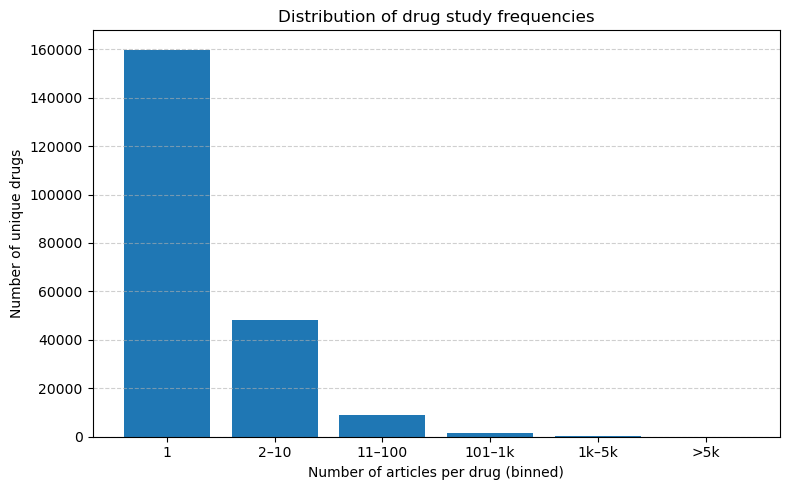

In [5]:
# Usage
bin_counts = plot_drug_count_hist(terms)

In [6]:
terms_common = terms[terms['n_articles']>1]
terms_common

,drug_term_umls_norm_manual_clean,n_articles,count_bin
0,Dexamethasone,5865,>5k
1,Acetylcysteine,4463,1k–5k
2,Doxorubicin,4411,1k–5k
3,NG-Nitroarginine Methyl Ester,4166,1k–5k
4,Sirolimus,3839,1k–5k
...,...,...,...
58680,AGN 194310,2,2–10
58681,67cu -,2,2–10
58682,verapamil and diltiazem,2,2–10
58683,AGN 204396,2,2–10


In [7]:
terms_common_list = list(terms_common['drug_term_umls_norm_manual_clean'])

In [8]:
approved_index = build_approved_index(terms_common_list)

In [9]:
approved_index[:5]

[('Dexamethasone', 'dexamethasone'),
 ('Acetylcysteine', 'acetylcysteine'),
 ('Doxorubicin', 'doxorubicin'),
 ('NG-Nitroarginine Methyl Ester', 'ng-nitroarginine methyl ester'),
 ('Sirolimus', 'sirolimus')]

## fetch via FDA API

In [10]:
def first_fda_approval_details(drug):
    q = f'openfda.generic_name:"{drug}"'
    try:
        resp = requests.get(
            "https://api.fda.gov/drug/drugsfda.json",
            params={"search": q, "limit": 100}
        )
        resp.raise_for_status()
    except requests.HTTPError as e:
        if resp.status_code == 404:
            return None
        else:
            raise

    records = resp.json().get("results", [])

    orig_subs = []
    for rec in records:
        for sub in rec.get("submissions", []):
            if sub.get("submission_type") in ("ORIG", "NDA", "BLA"):
                date = pd.to_datetime(sub["submission_status_date"],
                                      format="%Y%m%d",
                                      errors="coerce")
                if pd.notna(date):
                    orig_subs.append({
                        "date": date,
                        "submission": sub,
                        "record": rec
                    })

    if not orig_subs:
        return None

    first = min(orig_subs, key=lambda x: x["date"])
    sub = first["submission"]
    rec = first["record"]
    openfda = rec.get("openfda", {})

    return {
        "generic_name": drug,
        "sponsor_name": rec.get("sponsor_name"),
        "application_number": rec.get("application_number"),
        "submission_type": sub.get("submission_type"),
        "submission_number": sub.get("submission_number"),
        "approval_date": first["date"],
        "indication": rec.get("products", [{}])[0].get("indication"),
        "pharm_class_cs": openfda.get("pharm_class_cs"),
        "pharm_class_epc": openfda.get("pharm_class_epc"),
        "pharm_class_pe": openfda.get("pharm_class_pe"),
        "pharm_class_moa": openfda.get("pharm_class_moa")
    }


In [101]:
LABEL_BASE = "https://api.fda.gov/drug/label.json"

def fetch_application_label_details(app_nr):
    params = {
        "search": f'openfda.application_number:"{app_nr}"',
        "limit": 1,
        "sort": "effective_time:desc"
    }
    
    res = requests.get(LABEL_BASE, params=params, timeout=30)
    data = res.json()
    
    if "results" not in data:
        #print("No results found or bad request.")
        return "No results found or bad request.", "No results found or bad request.", "No results found or bad request."
    else:
        result = data["results"][0]
    
        # --- Extract clinical studies text and find all NCT IDs
        clinical_text = " ".join(result.get("clinical_studies", []))
        nct_ids = re.findall(r"NCT\d{8}", clinical_text)
        
        # --- Extract only the first sentence from indications_and_usage
        indications_text = " ".join(result.get("indications_and_usage", []))
        match = re.match(r"^(.*?\.)\s", indications_text)
        first_sentence = match.group(1).strip() if match else indications_text.strip()

        brand_name = " ".join(result.get("brand_name", []))
         
        nct_ids_str = ", ".join(nct_ids) if nct_ids else "No NCTIDs found."

        return nct_ids_str, first_sentence, indications_text
        
def all_fda_approval_details(drug):
    q = f'openfda.generic_name:"{drug}"'
    try:
        resp = requests.get(
            "https://api.fda.gov/drug/drugsfda.json",
            params={"search": q, "limit": 100}
        )
        resp.raise_for_status()
    except requests.HTTPError as e:
        if resp.status_code == 404:
            return None
        else:
            raise

    records = resp.json().get("results", [])

    orig_subs = []
    for rec in records:
        for sub in rec.get("submissions", []):
            if sub.get("submission_type") in ("ORIG", "NDA", "BLA"):
                date = pd.to_datetime(sub["submission_status_date"],
                                      format="%Y%m%d",
                                      errors="coerce")
                if pd.notna(date):
                    orig_subs.append({
                        "date": date,
                        "submission": sub,
                        "record": rec
                    })

    if not orig_subs:
        return None

    full_orig_records = []

    for orig_record in orig_subs:
    
        #first = min(orig_subs, key=lambda x: x["date"])
        sub = orig_record["submission"]
        rec = orig_record["record"]
        openfda = rec.get("openfda", {})
        app_nr = rec.get("application_number")
        nct_ids_str, first_sentence, indications_text = fetch_application_label_details(app_nr)
        
        full_orig_records.append({
        "generic_name": drug,
        "brand_name": openfda.get("brand_name"),
        "sponsor_name": rec.get("sponsor_name"),
        "application_number": app_nr,
        "submission_type": sub.get("submission_type"),
        "submission_number": sub.get("submission_number"),
        "approval_date": sub.get("submission_status_date"),
        "nct_ids_str": nct_ids_str,
        "indications_label_first_sent": first_sentence,
        "indication": rec.get("products", [{}])[0].get("indication"),
        "pharm_class_cs": openfda.get("pharm_class_cs"),
        "pharm_class_epc": openfda.get("pharm_class_epc"),
        "pharm_class_pe": openfda.get("pharm_class_pe"),
        "pharm_class_moa": openfda.get("pharm_class_moa")
    })

    return full_orig_records


In [102]:
all_fda_approval_details("cladribine")

4


[{'generic_name': 'cladribine',
  'brand_name': ['CLADRIBINE'],
  'sponsor_name': 'HIKMA',
  'application_number': 'ANDA075405',
  'submission_type': 'ORIG',
  'submission_number': '1',
  'approval_date': '20000228',
  'nct_ids_str': 'No NCTIDs found.',
  'indications_label_first_sent': 'INDICATIONS AND USAGE Cladribine Injection, USP is indicated for the treatment of active Hairy Cell Leukemia as defined by clinically significant anemia, neutropenia, thrombocytopenia or disease-related symptoms.',
  'indication': None,
  'pharm_class_cs': None,
  'pharm_class_epc': ['Purine Antimetabolite [EPC]'],
  'pharm_class_pe': None,
  'pharm_class_moa': None},
 {'generic_name': 'cladribine',
  'brand_name': ['CLADRIBINE'],
  'sponsor_name': 'FRESENIUS KABI USA',
  'application_number': 'ANDA076571',
  'submission_type': 'ORIG',
  'submission_number': '1',
  'approval_date': '20040422',
  'nct_ids_str': 'No NCTIDs found.',
  'indications_label_first_sent': 'INDICATIONS AND USAGE: Cladribine Inje

In [11]:
first_fda_approval_details("fampridine")

In [12]:
first_fda_approval_details("cladribine")

{'generic_name': 'cladribine',
 'sponsor_name': 'HIKMA',
 'application_number': 'ANDA075405',
 'submission_type': 'ORIG',
 'submission_number': '1',
 'approval_date': Timestamp('2000-02-28 00:00:00'),
 'indication': None,
 'pharm_class_cs': None,
 'pharm_class_epc': ['Purine Antimetabolite [EPC]'],
 'pharm_class_pe': None,
 'pharm_class_moa': None}

In [4]:
first_fda_approval_details("dalfampridine")

{'generic_name': 'dalfampridine',
 'sponsor_name': 'MERZ',
 'application_number': 'NDA022250',
 'submission_type': 'ORIG',
 'submission_number': '1',
 'approval_date': Timestamp('2010-01-22 00:00:00'),
 'indication': None,
 'pharm_class_cs': None,
 'pharm_class_epc': ['Potassium Channel Blocker [EPC]'],
 'pharm_class_pe': None,
 'pharm_class_moa': ['Potassium Channel Antagonists [MoA]']}

In [38]:
CHECKPOINT_EVERY = 1000
OUTPUT_PATH = "out/fda_drug_metadata_progress.csv"

# --- Resume if checkpoint exists ---
if os.path.exists(OUTPUT_PATH):
    df_existing = pd.read_csv(OUTPUT_PATH)
    processed = set(df_existing["canonical_drug_name"])
    print(f"🔁 Resuming from checkpoint — {len(processed)} drugs already processed.")
else:
    df_existing = pd.DataFrame()
    processed = set()

records = []

# tqdm progress bar over all drugs
for canonical_drug_name, drug in tqdm(approved_index, desc="Processing drugs"):
    if canonical_drug_name in processed:
        continue  # skip already processed

    details = first_fda_approval_details(drug)

    # Try reversed form if first failed
    if not details:
        drug_parts = drug.split()
        if len(drug_parts) == 2:
            drug_name_reversed = f"{drug_parts[1]} {drug_parts[0]}"
            details = first_fda_approval_details(drug_name_reversed)

    # Extract metadata safely
    approval_date = details.get("approval_date") if details else None
    epc = details.get("pharm_class_epc") if details else None
    moa = details.get("pharm_class_moa") if details else None
    sponsor_name = details.get("sponsor_name") if details else None

    records.append({
        "canonical_drug_name": canonical_drug_name,
        "queried_name": drug,
        "approval_year": approval_date.year if approval_date else None,
        "pharm_class_epc": epc,
        "pharm_class_moa": moa,
        "sponsor_name": sponsor_name
    })

    # Checkpoint every N new records
    if len(records) % CHECKPOINT_EVERY == 0:
        df_new = pd.DataFrame(records)
        df_ckpt = pd.concat([df_existing, df_new], ignore_index=True)
        df_ckpt.drop_duplicates(subset=["canonical_drug_name"], keep="last", inplace=True)
        df_ckpt.to_csv(OUTPUT_PATH, index=False)
        print(f"💾 Checkpoint saved ({len(df_ckpt)} total rows).")
        df_existing = df_ckpt.copy()

# --- Final save ---
df_final = pd.concat([df_existing, pd.DataFrame(records)], ignore_index=True)
df_final.drop_duplicates(subset=["canonical_drug_name"], keep="last", inplace=True)
df_final.to_csv(OUTPUT_PATH, index=False)
print(f"\n✅ Done! Saved full table with {len(df_final)} rows to {OUTPUT_PATH}")

Processing drugs:   2%|▏         | 1000/58685 [14:48<16:48:10,  1.05s/it]

💾 Checkpoint saved (1000 total rows).


Processing drugs:   3%|▎         | 2000/58685 [30:34<12:59:00,  1.21it/s]

💾 Checkpoint saved (2000 total rows).


Processing drugs:   5%|▌         | 3000/58685 [47:09<13:02:03,  1.19it/s] 

...

💾 Checkpoint saved (22000 total rows).


Processing drugs:  39%|███▉      | 23000/58685 [6:30:11<8:11:27,  1.21it/s] 

💾 Checkpoint saved (23000 total rows).


Processing drugs:  40%|████      | 23503/58685 [6:38:39<9:56:45,  1.02s/it] 


HTTPError: 429 Client Error: Too Many Requests for url: https://api.fda.gov/drug/drugsfda.json?search=openfda.generic_name%3A%22xylometazoline%22&limit=100

In [29]:
drug_years

{'Alemtuzumab': 2001,
 'Cladribine': 2000,
 'Fumarate, Dimethyl': 2013,
 'Fampridine': None,
 'Fingolimod': 2010,
 'Acetate, Glatiramer': 1996,
 'beta 1 Interferon': None,
 'Monomethyl fumarate': 2020,
 'Natalizumab': 2004,
 'ocrelizumab': 2017,
 'ofatumumab': 2009,
 'ozanimod': 2020,
 'peginterferon beta-1a': 2014,
 'ponesimod': 2021,
 'riTUXimab': 1997,
 'siponimod': 2019,
 'teriflunomide': 2012}

### Drugs Website

In [41]:
USER_AGENT = (
    "Mozilla/5.0 (compatible; FDAYearScraper/1.0; +your-email-or-repo)"
)

# ----------------------------------------------------------------------
# Low-level page fetcher  →  integer year | None
# ----------------------------------------------------------------------
def _year_from_history_page(slug: str, session: requests.Session) -> int | None:
    """
    Try https://www.drugs.com/history/<slug>.html and pull 'First approved <YEAR>'
    Returns the int YEAR or None if not found / 404 / parse fail.
    """
    url = f"https://www.drugs.com/history/{slug}.html"
    print(f"try {url}")
    try:
        r = session.get(url, headers={"User-Agent": USER_AGENT}, timeout=(5, 15))
        if r.status_code == 404:           # saves a soup parse if the page is absent
            print(f"[ERROR] status_code 404")
            return None
        r.raise_for_status()
    except requests.RequestException:
        print(f"[ERROR] Failed to fetch {url}: {e}")
        return None                        # network error, SSL issue, etc.

    soup = BeautifulSoup(r.text, "html.parser")
    node = soup.find(string=re.compile(r"First approved", re.I))
    if not node:
        return None

    m = re.search(r"\b(\d{4})\b", node)
    return int(m.group(1)) if m else None


# ----------------------------------------------------------------------
# Heuristic slug generator  (very lightweight “slugify”)
# e.g. "Fumarate, Dimethyl" → ["fumarate-dimethyl", "dimethyl-fumarate"]
# ----------------------------------------------------------------------
def _candidate_slugs(drug_name: str) -> list[str]:
    """
    Generate possible Drugs.com history slugs from a drug name.
    Special cases handled (e.g., Fampridine → Dalfampridine).
    """
    # --- special synonyms / redirects ---
    if drug_name.strip().lower() == "fampridine":
        return ["dalfampridine"]

    # --- generic slug building ---
    words = re.sub(r"[^0-9a-zA-Z]+", " ", drug_name).lower().split()
    slugs = ["-".join(words)]

    # if original name had a comma, also try reversed word order
    if "," in drug_name:
        slugs.append("-".join(reversed(words)))

    # de-duplicate while preserving order
    return list(dict.fromkeys(slugs))


# ----------------------------------------------------------------------
# Public helper
# ----------------------------------------------------------------------
def fill_missing_approval_years(data: dict[str, int | None],
                                delay: float = 1.0) -> dict[str, int | None]:
    """
    Mutates and returns `data`, filling any None entries with the scraped year
    (or leaving None if the page/year is not found).
    `delay` pauses N seconds between hits to be polite.
    """
    session = requests.Session()

    for drug, yr in data.items():
        if yr is not None:
            continue                      # already have a year

        for slug in _candidate_slugs(drug):
            got = _year_from_history_page(slug, session)
            if got:
                data[drug] = got
                break                     # stop trying other slugs

        time.sleep(delay)                 # throttle

    return data



In [44]:
drug_years = fill_missing_approval_years(drug_years)

try https://www.drugs.com/history/dalfampridine.html
try https://www.drugs.com/history/beta-1-interferon.html
[ERROR] status_code 404


In [45]:
drug_years

{'Alemtuzumab': 2001,
 'Cladribine': 2000,
 'Fumarate, Dimethyl': 2013,
 'Fampridine': 2010,
 'Fingolimod': 2010,
 'Acetate, Glatiramer': 1996,
 'beta 1 Interferon': None,
 'Monomethyl fumarate': 2020,
 'Natalizumab': 2004,
 'ocrelizumab': 2017,
 'ofatumumab': 2009,
 'ozanimod': 2020,
 'peginterferon beta-1a': 2014,
 'ponesimod': 2021,
 'riTUXimab': 1997,
 'siponimod': 2019,
 'teriflunomide': 2012}

In [50]:
with open("outputs/drug_approval_years_MS.json", "w", encoding="utf-8") as f:
    json.dump(drug_years, f, indent=2, ensure_ascii=False)

## FDA Data Stats

In [76]:
drugs_approval_years = pd.read_csv("./out/fda_drug_metadata_progress.csv")
drugs_approval_years.shape

(45000, 6)

In [79]:
drugs_approval_years_clean = drugs_approval_years.dropna()
drugs_approval_years_clean.shape

(503, 6)

In [80]:
drugs_approval_years_clean

,canonical_drug_name,queried_name,approval_year,pharm_class_epc,pharm_class_moa,sponsor_name
0,Dexamethasone,dexamethasone,1962.0,['Corticosteroid [EPC]'],['Corticosteroid Hormone Receptor Agonists [Mo...,HARROW EYE
1,Acetylcysteine,acetylcysteine,1994.0,"['Antidote [EPC]', 'Antidote for Acetaminophen...",['Reduction Activity [MoA]'],HOSPIRA
4,Sirolimus,sirolimus,1999.0,"['mTOR Inhibitor Immunosuppressant [EPC]', 'Ki...","['mTOR Inhibitors [MoA]', 'Protein Kinase Inhi...",PF PRISM CV
9,Indomethacin,indomethacin,1984.0,['Nonsteroidal Anti-inflammatory Drug [EPC]'],['Cyclooxygenase Inhibitors [MoA]'],CHARTWELL MOLECULES
11,Cyclosporine,cyclosporine,1983.0,['Calcineurin Inhibitor Immunosuppressant [EPC]'],"['Calcineurin Inhibitors [MoA]', 'Cytochrome P...",NOVARTIS
...,...,...,...,...,...,...
39447,relatlimab,relatlimab,2022.0,['Programmed Death Receptor-1 Blocking Antibod...,['Programmed Death Receptor-1-directed Antibod...,BRISTOL MYERS SQUIBB
39559,pozelimab,pozelimab,2023.0,['Complement Inhibitor [EPC]'],['Complement Inhibitors [MoA]'],REGENERON PHARMACEUTICALS
40456,brodalumab,brodalumab,2017.0,['Interleukin-17 Receptor A Antagonist [EPC]'],['Interleukin 17 Receptor A Antagonists [MoA]'],VALEANT LUXEMBOURG
41524,recombinant,recombinant,2020.0,"['CD38-directed Cytolytic Antibody [EPC]', 'En...",['CD38-directed Antibody Interactions [MoA]'],JANSSEN BIOTECH


/sctmp/sdonev/ipykernel_1146665/1931622131.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugs_approval_years_clean["approval_year"] = pd.to_numeric(


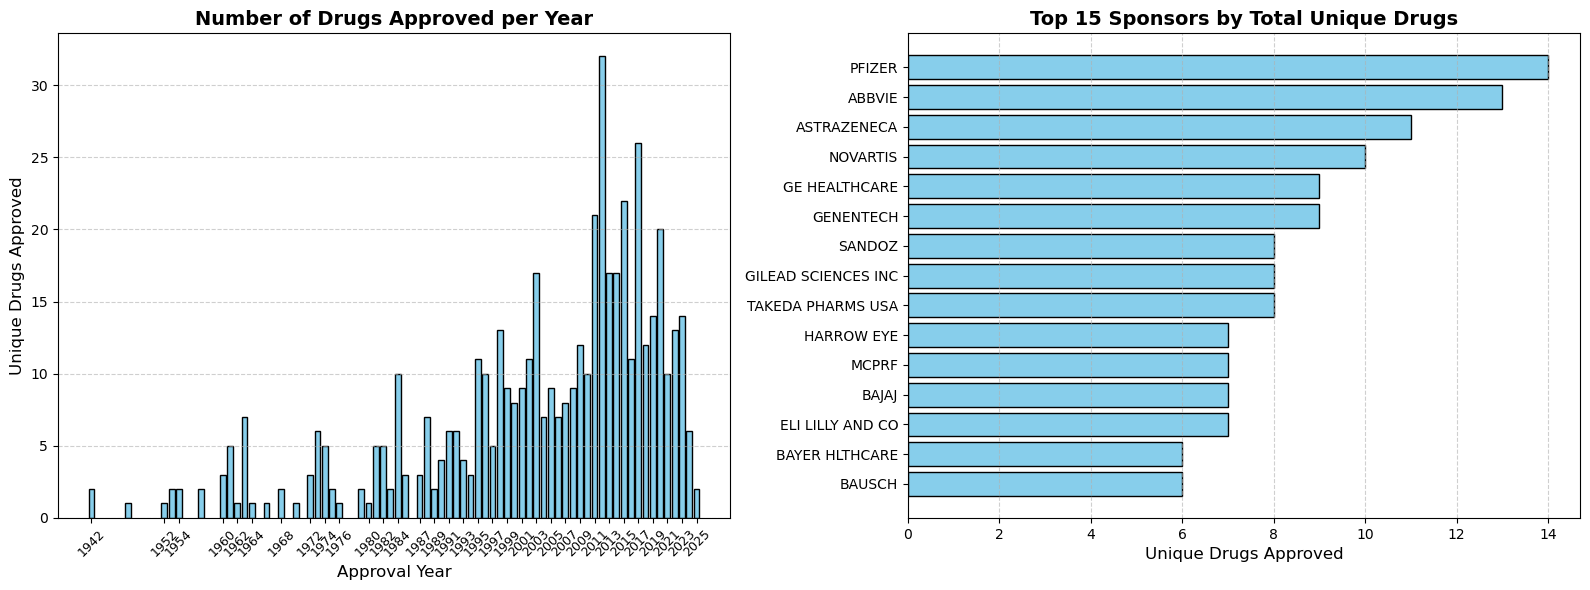

In [87]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Clean and prepare the data ---
drugs_approval_years_clean["approval_year"] = pd.to_numeric(
    drugs_approval_years_clean["approval_year"], errors="coerce"
)
df = drugs_approval_years_clean.dropna(subset=["approval_year", "sponsor_name"])

# --- Group 1: Drug count per year ---
drug_counts = (
    df.groupby("approval_year")["canonical_drug_name"]
    .nunique()
    .sort_index()
)

# --- Group 2: Drug count per sponsor ---
sponsor_counts = (
    df.groupby("sponsor_name")["canonical_drug_name"]
    .nunique()
    .sort_values(ascending=False)
)

# --- Create side-by-side plots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Drugs per year ---
axes[0].bar(drug_counts.index, drug_counts.values, color="skyblue", edgecolor="black")
axes[0].set_title("Number of Drugs Approved per Year", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Approval Year", fontsize=12)
axes[0].set_ylabel("Unique Drugs Approved", fontsize=12)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# Show every 2nd year tick for readability
years = drug_counts.index.astype(int)
axes[0].set_xticks(years[::2])
axes[0].set_xticklabels(years[::2], rotation=45, fontsize=9)

# --- Plot 2: Drugs per sponsor ---
top_n = 15  # show top 15 sponsors
top_sponsors = sponsor_counts.head(top_n)

axes[1].barh(top_sponsors.index[::-1], top_sponsors.values[::-1], color="skyblue", edgecolor="black")
axes[1].set_title(f"Top {top_n} Sponsors by Total Unique Drugs", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Unique Drugs Approved", fontsize=12)
axes[1].grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [85]:
drugs_approval_years_clean[drugs_approval_years_clean['approval_year']>=2015]

,canonical_drug_name,queried_name,approval_year,pharm_class_epc,pharm_class_moa,sponsor_name
273,gefitinib,gefitinib,2015.0,['Kinase Inhibitor [EPC]'],['Protein Kinase Inhibitors [MoA]'],ASTRAZENECA
652,olaparib,olaparib,2017.0,['Poly(ADP-Ribose) Polymerase Inhibitor [EPC]'],['Poly(ADP-Ribose) Polymerase Inhibitors [MoA]'],ASTRAZENECA
811,venetoclax,venetoclax,2016.0,['BCL-2 Inhibitor [EPC]'],['P-Glycoprotein Inhibitors [MoA]'],ABBVIE
889,palbociclib,palbociclib,2015.0,['Kinase Inhibitor [EPC]'],"['Kinase Inhibitors [MoA]', 'Cytochrome P450 3...",PFIZER
919,Dactinomycin,dactinomycin,2017.0,['Actinomycin [EPC]'],"['Nucleic Acid Synthesis Inhibitors [MoA]', 'P...",EUGIA PHARMA
...,...,...,...,...,...,...
39447,relatlimab,relatlimab,2022.0,['Programmed Death Receptor-1 Blocking Antibod...,['Programmed Death Receptor-1-directed Antibod...,BRISTOL MYERS SQUIBB
39559,pozelimab,pozelimab,2023.0,['Complement Inhibitor [EPC]'],['Complement Inhibitors [MoA]'],REGENERON PHARMACEUTICALS
40456,brodalumab,brodalumab,2017.0,['Interleukin-17 Receptor A Antagonist [EPC]'],['Interleukin 17 Receptor A Antagonists [MoA]'],VALEANT LUXEMBOURG
41524,recombinant,recombinant,2020.0,"['CD38-directed Cytolytic Antibody [EPC]', 'En...",['CD38-directed Antibody Interactions [MoA]'],JANSSEN BIOTECH
